# InterScale Pipeline: Combined model

1. Local Model = GCN
2. Global Model = Self-attention transformer

Data: Legnini et. al. 

In [1]:
import scanpy as sc
import numpy as np

import InterScale as interscale
from InterScale.config import load_config
#from graph_transformer_long_range_niches.pp import split_adata
from InterScale.tl import prepare_geome_dataset, check_and_update_cfg
from InterScale.geome_dataloader import GraphAnnDataModule

/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readth

In [2]:
CFG_PATH_REG = "/Users/sara.jimenez/Documents/Projects/Long_range_interactions/configs/configs/legnini23_combined.yaml"

## 0. Load and prepare data

In [3]:
cfg = load_config(CFG_PATH_REG)
cfg

CfgNode({'wandb': CfgNode({'use': False, 'project_name': 'GTLongRange_Legnini23'}), 'model': CfgNode({'n_embed': 16, 'local_component': CfgNode({'name': 'GCN', 'load': None, 'parameters': CfgNode({'hidden_dim': 256, 'num_layers': 2, 'dropout_local': 0.1})}), 'global_component': CfgNode({'name': 'self-attn-transformer', 'load': None, 'parameters': CfgNode({'n_heads': 4, 'dim_feedforward': 256, 'dropout_global': 0.1, 'activation_func': 'relu', 'num_layers': 2, 'max_seq_len': 2000, 'long_range_attention': False})}), 'save': None, 'loss': None, 'decoder': CfgNode({'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1})}), 'optim': CfgNode({'accelerator': 'auto', 'lr': 0.001, 'lr_scheduler': 'CosineWarmupScheduler', 'lr_warmup': 20, 'lr_max_epochs': 100, 'wd': 0.0001, 'loss': 'GaussianNLL', 'seed': 44, 'cross_corr': 'cell', 'n_epochs': 100, 'early_stopping': True}), 'dataset': CfgNode({'h5ad_data': '/Users/sara.jimenez/Documents/Projects/Long_range_interactions/data/legnini23.

In [4]:
adata = sc.read_h5ad(cfg.dataset.h5ad_data)
adata

AnnData object with n_obs × n_vars = 43762 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

Remove cells with zero expression across all genes. Gives error for pearson correlation.

In [5]:
zero_expression_cells = np.array((adata.X.sum(axis=1) == 0)).flatten()
print(f"Nr. of zero expression cells: {zero_expression_cells.sum()}")
nonzero_cells = np.array((adata.X.sum(axis=1) != 0)).flatten()
adata = adata[nonzero_cells].copy()

Nr. of zero expression cells: 648


In [6]:
import pandas as pd
# Creating a DataFrame from 'split', 'fov', and 'condition'
df = adata.obs[['split', 'sample', 'condition']]
value_counts = pd.DataFrame(df.values, columns=df.columns).value_counts()
print(value_counts)

split  sample       condition
train  slide1_D2-2  SHH          4299
       slide1_D2-3  SHH          3516
       slide1_C2-2  SHH          3350
val    slide1_B2-1  SHH          3284
train  slide4_B2-1  SHH          3175
       slide1_A2-1  SHH          3023
       slide1_C2-1  Ctrl         2870
       slide4_A2-1  SHH          2626
       slide4_A2-2  SHH          2505
val    slide1_B2-3  SHH          2134
test   slide4_A2-3  Ctrl         1983
train  slide1_C2-5  Ctrl         1938
test   slide4_B2-2  SHH          1772
train  slide1_B2-2  Ctrl         1699
val    slide1_A2-2  SHH          1691
       slide1_C2-3  Ctrl         1627
       slide4_B2-3  Ctrl         1622
Name: count, dtype: int64


## 1. Data setup

We need to specify:

- `prediction_task`: Prediction task can either be classification or regression
- `prediction_level`: Which level the predictions should be performed on: either (1) tissue label, e.i. condition (`graph`), (2) node label (`node`) for cell type or niche prediciton, or (3) GEX prediction.

Additionally, we define dataset specific keys: 
- `prediction_obs`: Label in `adata.obs` to be predicted. Only required for classification tasks.
- `layer_key`: Defines which GEX matrix to retrieve from `adata.layer`
- `sample_key`: `adata.obs` used to split the samples into PyG Data objects
- `group_label`: Optional: only if we have a `adata.obs` group that we want to stratify during sampling

In [7]:
PREDICTION_TASK = 'regression'
PREDICTION_LEVEL = 'node'

#prediction_obs = 'condition'
layer_key = 'log1p_norm'
sample_key = ['sample']
group_label = 'condition'

In [8]:
cfg = check_and_update_cfg(
    cfg, 
    prediction_task = PREDICTION_TASK, 
    prediction_level = PREDICTION_LEVEL, 
    layer_key = layer_key, 
    sample_key = sample_key, 
    #prediction_obs = prediction_obs
)

Update prediction task (from 'node_regression' to 'regression')
Update layer key (from 'None' to 'log1p_norm')
Update sample key (from '['sample']' to '['sample']')
Update group label (from '' to 'None')


In [9]:
interscale.model.CombinedModel._setup_anndata(
    adata = adata, 
    prediction_task = PREDICTION_TASK, 
    layer_key = layer_key, 
    sample_key_list = sample_key, 
    #prediction_obs = prediction_obs, 
    group_key = group_label
)

/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[log1p_norm] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


Anndata setup with scvi-tools version 1.3.2.

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│   n_group_key    │   2   │
│  n_sample_key_0  │  17   │
│       n_x        │  88   │
└──────────────────┴───────┘

                  Data Registry                   
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃       scvi-tools Location       ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  group_key   │  adata.obs['_scvi_group_key']   │
│ sample_key_0 │ adata.obs['_scvi_sample_key_0'] │
│      x       │   adata.layers['log1p_norm']    │
└──────────────┴─────────────────────────────────┘

                sample_key_0 State Registry                
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories  ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ slide1_A2-1 │          0          │
│                     │ slide1_A2-2 │          1          │
│                     │ slide1_B2-1 │          2          │
│                     │ slide1_B2-2 │          3          │
│                     │ slide1_B2-3 │          4          │
│                     │ slide1_C2-1 │          5          │
│                     │ slide1_C2-2 │          6          │
│                     │ slide1_C2-3 │          7          │
│                     │ slide1_C2-5 │          8          │
│                     │ slide1_D2-2 │          9          │
│                     │ slide1_D2-3 │         10          │
│                     │ slide4_A2-1 │         11          │
│                     │ slide4_A2-2 │         12          │
│                     │ slide4_A2-3 │         13          │
│                     │ slide4_B2-1 │         14          │
│                     │ slide4_B2-2 │         15          │
│                     │ slide4_B2-3 │         16          │
└─────────────────────┴─────────────┴─────────────────────┘

                  group_key State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃    Source Location     ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['condition'] │    Ctrl    │          0          │
│                        │    SHH     │          1          │
└────────────────────────┴────────────┴─────────────────────┘

## 2. Model setup

In [10]:
model = interscale.model.CombinedModel(
    adata,
    cfg = cfg
)

/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [11]:
model._model_summary_string

'regression model for node prediction. \nCombined Module: \nLocal Module: GCN Local Component: \nn_layers: 2, \nn_hidden: 256, \nn_embed: 16, \ndropout_local: 0.1\nGlobal Module: Transformer Encoder Global Component: \nmax_seq_len: 2000, \nn_heads: 4, \nact_func: relu, \nnum_layers: 2, \n\n'

## 3. Training

In [12]:
#split_adata(adata, split_obs='sample', val_size=cfg.dataset.val_size, test_size=cfg.dataset.test_size, seed = cfg.optim.seed, stratify_groups = cfg.dataset.group_label)
pyg_data_list, _ = prepare_geome_dataset(adata, cfg)
dm = GraphAnnDataModule(datas=pyg_data_list, 
                           num_workers=1, 
                           batch_size=int(cfg.dataset.batch_size), 
                           pct_mask_nodes=cfg.dataset.pct_mask_nodes,
                           learning_type="node")

Split key split already exists in adata.obs


In [13]:
cfg.dataset

CfgNode({'h5ad_data': '/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/legnini23.h5ad', 'name': 'legnini23', 'description': '', 'prediction_task': 'regression', 'prediction_obs': None, 'prediction_level': 'node', 'layer_key': 'log1p_norm', 'sample_key': ['sample'], 'group_label': None, 'split_key': 'split', 'spatial_neigbors_kwargs': CfgNode({'radius': 200, 'coord_type': 'generic', 'library_key': 'sample', 'n_neighs': 6}), 'batch_size': 3, 'train_size': 0.7, 'val_size': 0.2, 'test_size': 0.1, 'num_features': -1, 'num_classes': -1, 'stratify_group': None, 'pct_mask_nodes': 0.3, 'segmentation_robustness': None})

In [14]:
# for now training only works with datamodule. TODO: Add DataSplitter for datamodule independent training.
model.train(max_epochs = 100, 
            datamodule = dm,
            #batch_size=int(cfg.dataset.batch_size),
            #train_size=int(cfg.dataset.train_size),
            #validation_size=int(cfg.dataset.val_size),
            early_stopping = True)

[rank: 0] Seed set to 44


Steps per epoch 4
cross-cell per gene correlation metrics


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA A100-PCIE-40GB MIG 3g.20gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:751: Checkpoint directory /ictstr01/groups/ml01/workspace/sara.jimenez/InterScale/GT-long-range-niches/docs/notebooks/lightning_logs/version_31155799/checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBL

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│   val_cosine_similarity   │    0.8749908804893494     │
│         val_loss          │    0.14906461536884308    │
│          val_mse          │    0.33673611283302307    │
│     val_pearson_corr      │    0.06386220455169678    │
│          val_r2           │    -1.7094975709915161    │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-c51c82f2-7e04-56a8-8b74-4211c9821715]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/aih/sara.jimenez/miniconda3/envs/interscale/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


on_test_epoch_end 65


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  test_cosine_similarity   │    0.9123885035514832     │
│         test_loss         │    0.11930517107248306    │
│         test_mse          │    0.25930505990982056    │
│     test_pearson_corr     │    0.1354774385690689     │
│          test_r2          │    -3.262038469314575     │
└───────────────────────────┴───────────────────────────┘


Early stopping triggered at epoch 64
Best val_mse: 0.3396


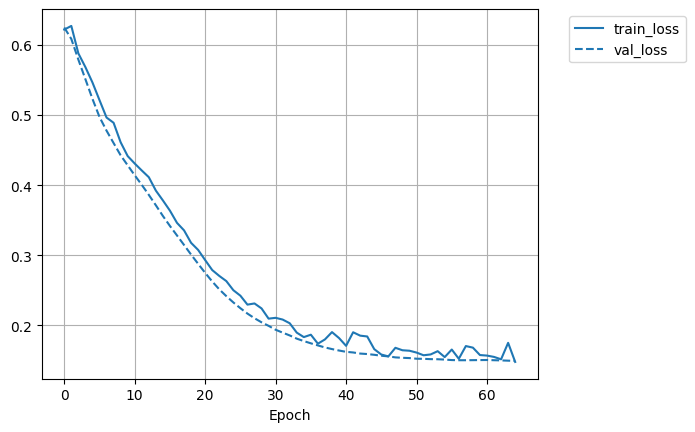

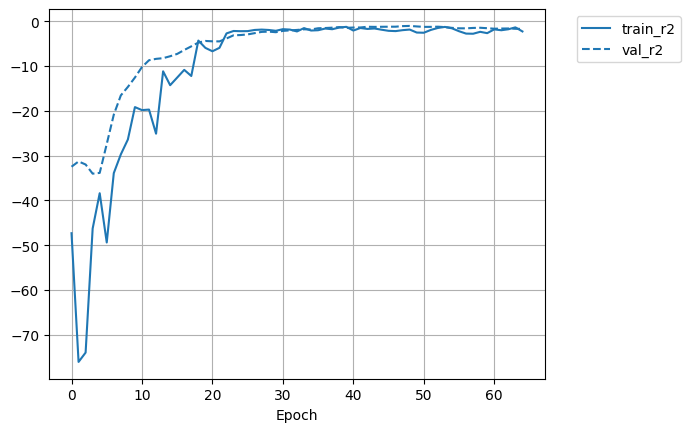

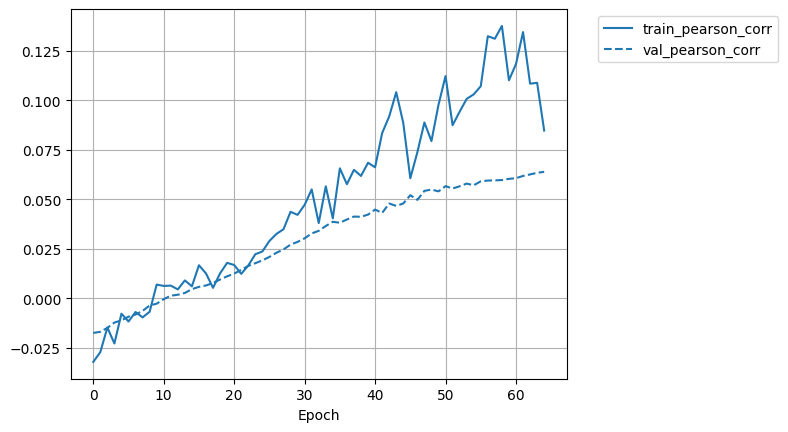

In [15]:
model.history_.plot_history(subset_term = 'loss')
model.history_.plot_history(subset_term = 'r2')
model.history_.plot_history(subset_term = 'pearson')

## 4. Model saving and loading

In [ ]:
model.save('/lustre/groups/ml01/workspace/sara.jimenez/InterScale/results/legnini23/model_lse_decoder/')

In [10]:
model = interscale.model.CombinedModel.load(
    '/Users/sara.jimenez/Documents/Projects/Long_range_interactions/results/model', 
    adata, 
    cfg,
    model_name='legnini23_regr_node_44_GCN_self-attn-transformer_linear_model',
)

Loading model from /Users/sara.jimenez/Documents/Projects/Long_range_interactions/results/model/legnini23_regr_node_44_GCN_self-attn-transformer_linear_modelmodel.pt
Try with .ckpt extension.
Unclear checkpoint format. Attempting remapping anyway.
State dict remapping applied. Source detected: unknown


/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/torch/nn/modules/transformer.py:282: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


In [11]:
model

## 5. Evaluation

Evaluation can either be run on the entire AnnData that the model was set up with or subsets of AnnData defined by sample_id from `adata.obs[sample_key]`.

In [12]:
adata

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_key'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw'

In [13]:
result = model.get_model_output(adata)

Load GEX from .layers/log1p_norm
call new


In [14]:
result

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_key', '_cls_horizontal', '_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred'

In [15]:
result.X.max(), result.layers['log1p_norm'].max()

(279.0, 5.6347895)

In [46]:
weights = model.module.decoder.decoder.weight.detach().numpy()
weights

array([[-0.1495623 , -0.16673833, -0.19430435, ..., -0.0029459 ,
        -0.20422566, -0.03137475],
       [ 0.01947066,  0.2424998 ,  0.23293126, ..., -0.07018998,
         0.00090179,  0.01929048],
       [-0.1744313 , -0.22758135,  0.03391218, ...,  0.00952989,
         0.07275018,  0.10062438],
       ...,
       [ 0.0422349 ,  0.21958458,  0.0756475 , ..., -0.10840797,
         0.12931374, -0.12819934],
       [ 0.18977344, -0.04626176,  0.11763424, ..., -0.00967073,
        -0.01448905,  0.19761291],
       [ 0.07624385, -0.1326158 , -0.18920612, ..., -0.00045106,
         0.03159124,  0.04228234]], dtype=float32)

In [47]:
weights.shape

(88, 16)

In [16]:
from InterScale.evaluation import gene_loadings
from InterScale.evaluation.gene_rank_analysis import predict_gene_r2, gene_rank_analysis

In [17]:
gene_loadings(
    result,
    model,
    layer_key="log1p_norm",
)

AnnData object with n_obs × n_vars = 43114 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_key', '_cls_horizontal', '_cls_vertical'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix'
    varm: '_std_gene_loadings'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred'

In [18]:
result.varm['_std_gene_loadings'].shape

(88, 16)

In [19]:
result.varm['_std_gene_loadings']

array([[-7.09665865e-02, -5.11519872e-02, -1.24344796e-01, ...,
        -1.50798960e-03, -7.87341073e-02, -1.15027344e-02],
       [ 1.10976622e-02,  8.93629491e-02,  1.79057240e-01, ...,
        -4.31593098e-02,  4.17615171e-04,  8.49537924e-03],
       [-5.73361099e-01, -4.83655155e-01,  1.50339425e-01, ...,
         3.37940492e-02,  1.94293693e-01,  2.55561888e-01],
       ...,
       [ 2.50739567e-02,  8.42846632e-02,  6.05702475e-02, ...,
        -6.94322437e-02,  6.23759069e-02, -5.88066205e-02],
       [ 1.57466280e+00, -2.48181596e-01,  1.31643438e+00, ...,
        -8.65685493e-02, -9.76816565e-02,  1.26694131e+00],
       [ 2.87907386e+00, -3.23771477e+00, -9.63599300e+00, ...,
        -1.83750726e-02,  9.69249070e-01,  1.23366165e+00]], dtype=float32)

In [20]:
Zg = np.asarray(adata.obsm["_global_emb"], dtype=np.float32)

print("Zg NaNs:", np.isnan(Zg).any())
print("Zg min/max:", np.nanmin(Zg), np.nanmax(Zg))
print("Zg std:", Zg.std(axis=0)[:10])

Zg NaNs: True
Zg min/max: -2.7185884 3.09229
Zg std: [nan nan nan nan nan nan nan nan nan nan]


In [45]:
Zg.shape

(43114, 16)

In [22]:
L = adata.varm["_std_gene_loadings"]
print("NaNs:", np.isnan(L).any())
print("Infs:", np.isinf(L).any())
print("Range:", np.min(L), np.max(L))

NaNs: False
Infs: False
Range: -9.635993 5.2552285


### Covariance analysis of embedding dimensions based on gene loadings

In [23]:
# Define multiple gene sets
gene_sets = {
    "ventral": ['NKX6.1', 'NKX2.2', 'FOXA1','FOXA2'],
    "dorsal": ['DBX1','DBX2', 'IRX3', 'PAX6']
}

In [24]:
from InterScale.evaluation import gene_set_covariance

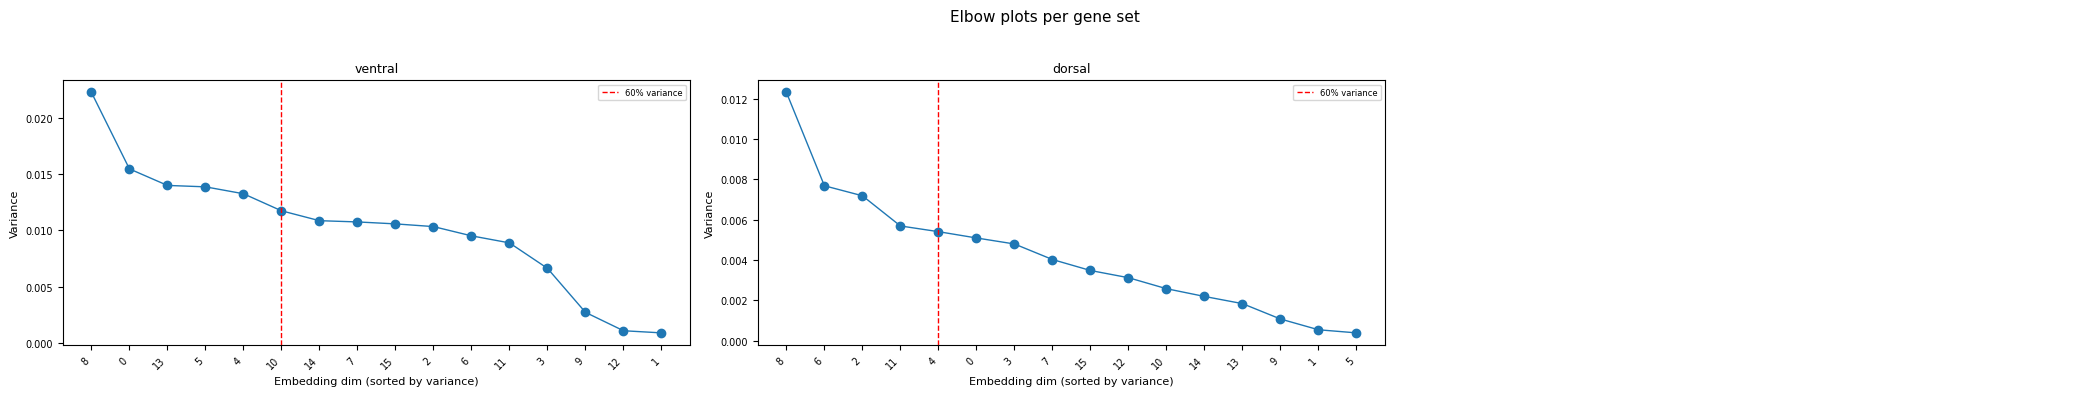

In [25]:
cov_df = gene_set_covariance(result, gene_sets, varm_key = '_std_gene_loadings', plot = True)

In [ ]:
gobal_cov_df = gene_set_covariance(result, gene_sets, varm_key = '_global_gene_loadings', plot = True)

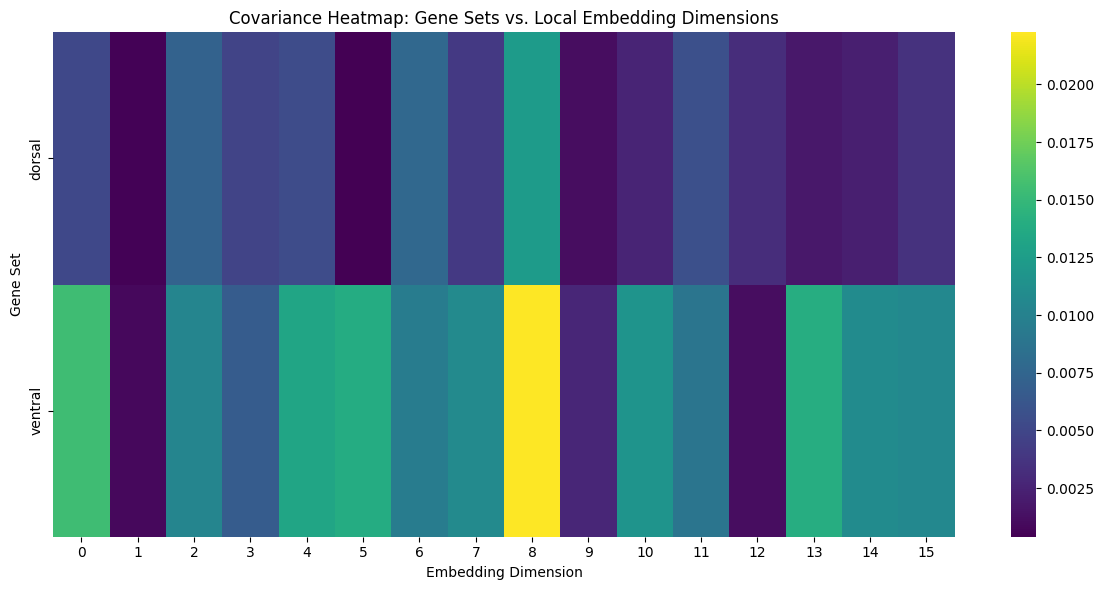

In [26]:
import matplotlib
#matplotlib.use('svg')  # Use SVG backend to avoid ft2font

import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the data
heatmap_data = cov_df.reset_index().pivot(
    index="gene_set", columns="embedding_dimension", values="covariance"
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="viridis")
plt.title("Covariance Heatmap: Gene Sets vs. Local Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()

In [ ]:
# Pivot the data
heatmap_data = gobal_cov_df.reset_index().pivot(
    index="gene_set", columns="embedding_dimension", values="covariance"
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="viridis")
plt.title("Covariance Heatmap: Gene Sets vs. Global Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()

#### Select single slide for evaluation

In [27]:
ctrl_test = result[result.obs['sample'] == 'slide4_B2-2']
ctrl_test.obs

,Cell,Area,x,y,sample,condition,organoid,obs_names,split,_scvi_sample_key_0,_scvi_group_key,_cls_horizontal,_cls_vertical
39721,W5A2_c1,12758.0,2049.352,1118.874,slide4_B2-2,SHH,organoid #3,W5A2_c1,test,15,1,8.774171e-12,1.557629e-13
39722,W5A2_c2,19453.0,2275.323,1170.405,slide4_B2-2,SHH,organoid #3,W5A2_c2,test,15,1,7.827637e-12,1.475208e-12
39723,W5A2_c3,9538.0,1181.378,1158.448,slide4_B2-2,SHH,organoid #3,W5A2_c3,test,15,1,1.181227e-11,1.026735e-13
39724,W5A2_c4,7787.0,2174.867,1198.309,slide4_B2-2,SHH,organoid #3,W5A2_c4,test,15,1,9.946533e-12,2.374941e-12
39725,W5A2_c5,24243.0,2441.575,1175.163,slide4_B2-2,SHH,organoid #3,W5A2_c5,test,15,1,7.012568e-12,6.687372e-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41488,W5A2_c1774,12233.0,5082.481,7911.868,slide4_B2-2,SHH,organoid #3,W5A2_c1774,test,15,1,1.104271e-11,5.802421e-12
41489,W5A2_c1775,11942.0,4843.871,7984.865,slide4_B2-2,SHH,organoid #3,W5A2_c1775,test,15,1,5.221571e-12,4.096328e-15
41490,W5A2_c1776,8348.0,4585.569,7983.518,slide4_B2-2,SHH,organoid #3,W5A2_c1776,test,15,1,3.503964e-12,0.000000e+00
41491,W5A2_c1777,10284.0,4479.319,8021.775,slide4_B2-2,SHH,organoid #3,W5A2_c1777,test,15,1,7.743172e-12,0.000000e+00


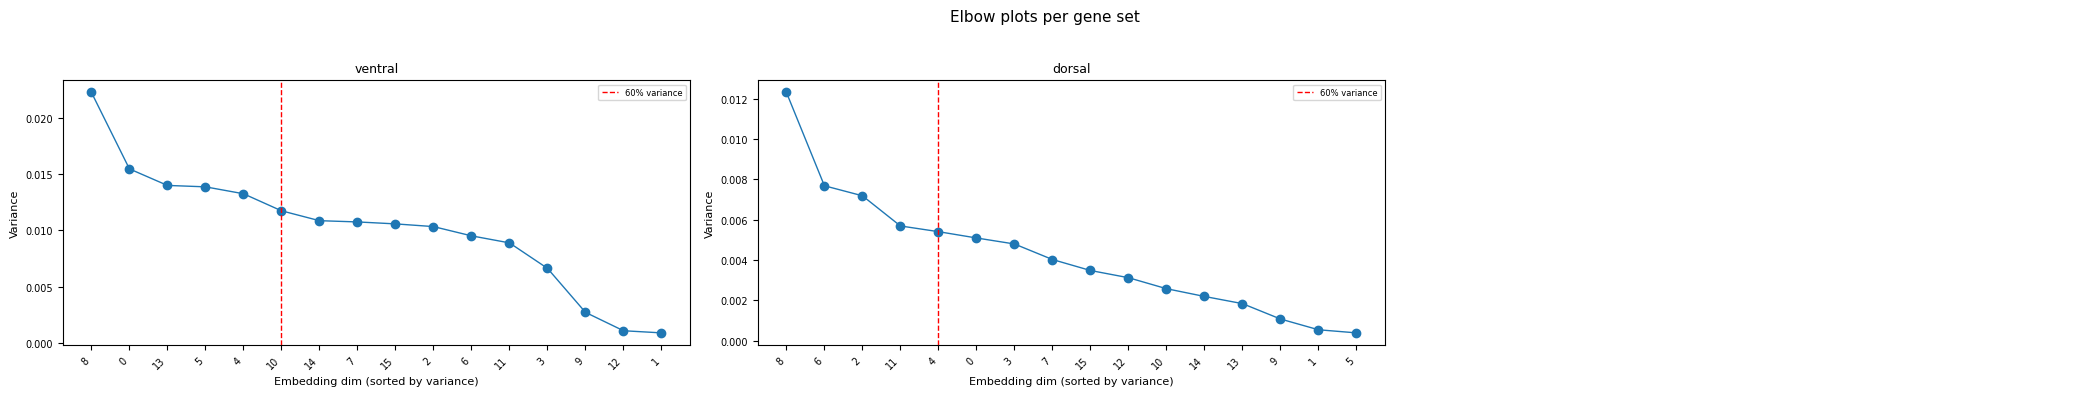

In [28]:
# Compute and display the results
cov_df_nd_test = gene_set_covariance(ctrl_test, gene_sets, varm_key = '_std_gene_loadings', plot = True)
#global_cov_df_nd_test = gene_set_covariance(ctrl_test, gene_sets, varm_key = '_global_gene_loadings', plot = True)

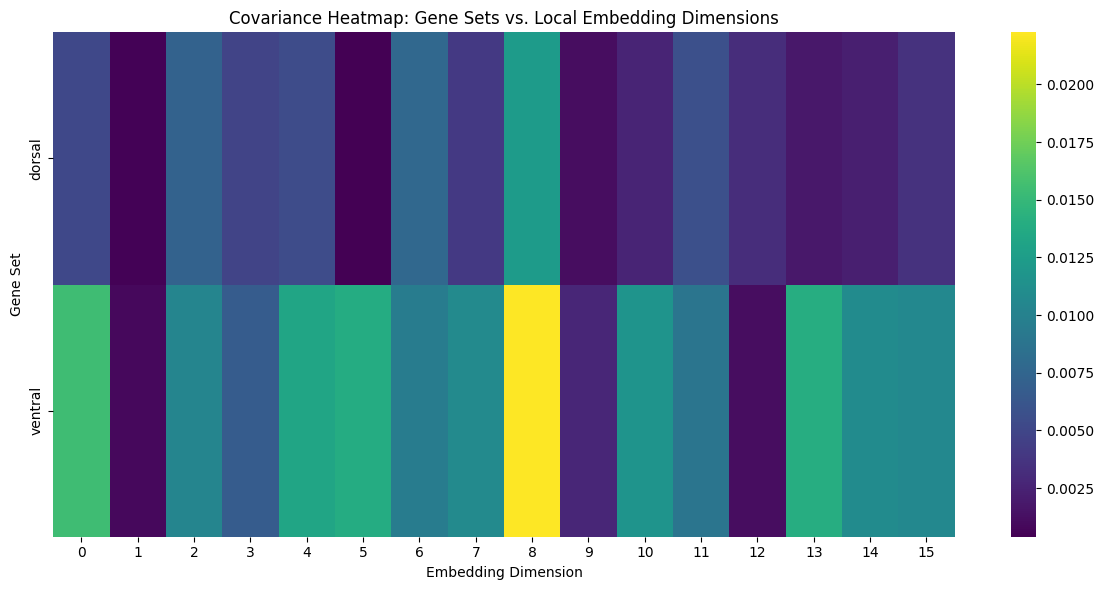

In [29]:
heatmap_data = cov_df_nd_test.reset_index().pivot(
    index="gene_set", columns="embedding_dimension", values="covariance"
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="viridis")
plt.title("Covariance Heatmap: Gene Sets vs. Local Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()

In [ ]:
heatmap_data = global_cov_df_nd_test.reset_index().pivot(
    index="gene_set", columns="embedding_dimension", values="covariance"
)

# Plot
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="viridis")
plt.title("Covariance Heatmap: Gene Sets vs. Global Embedding Dimensions")
plt.xlabel("Embedding Dimension")
plt.ylabel("Gene Set")
plt.tight_layout()
plt.show()

In [30]:
from InterScale.evaluation import spatial_covariance_plot

{'dorsal': 10}

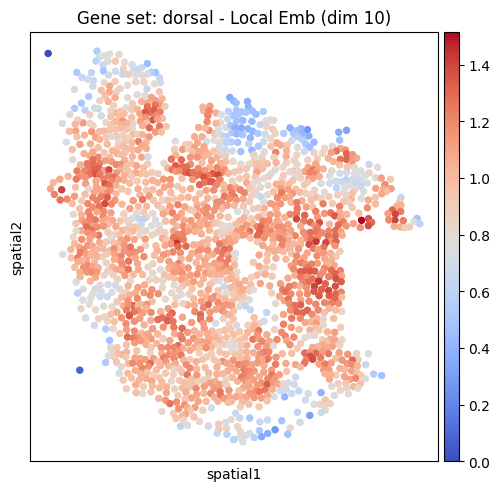

In [39]:
spatial_covariance_plot(
    ctrl_test,
    gene_sets = gene_sets,
    int_length = "local",   # "local" or "global", 
    restrict_to = "dorsal",
    emb_dim = 10, 
    cmap = "coolwarm"
)

{'ventral': 3}

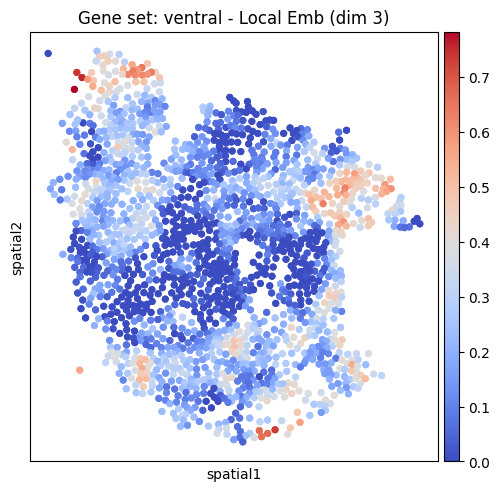

In [37]:
spatial_covariance_plot(
    ctrl_test,
    gene_sets = gene_sets,
    int_length = "local",   # "local" or "global", 
    restrict_to = "ventral",
    emb_dim = 3, 
    cmap = "coolwarm"
)

In [32]:
z_data  = (heatmap_data - heatmap_data.mean(axis=1).values[:, None]) / heatmap_data.std(axis=1).values[:, None]

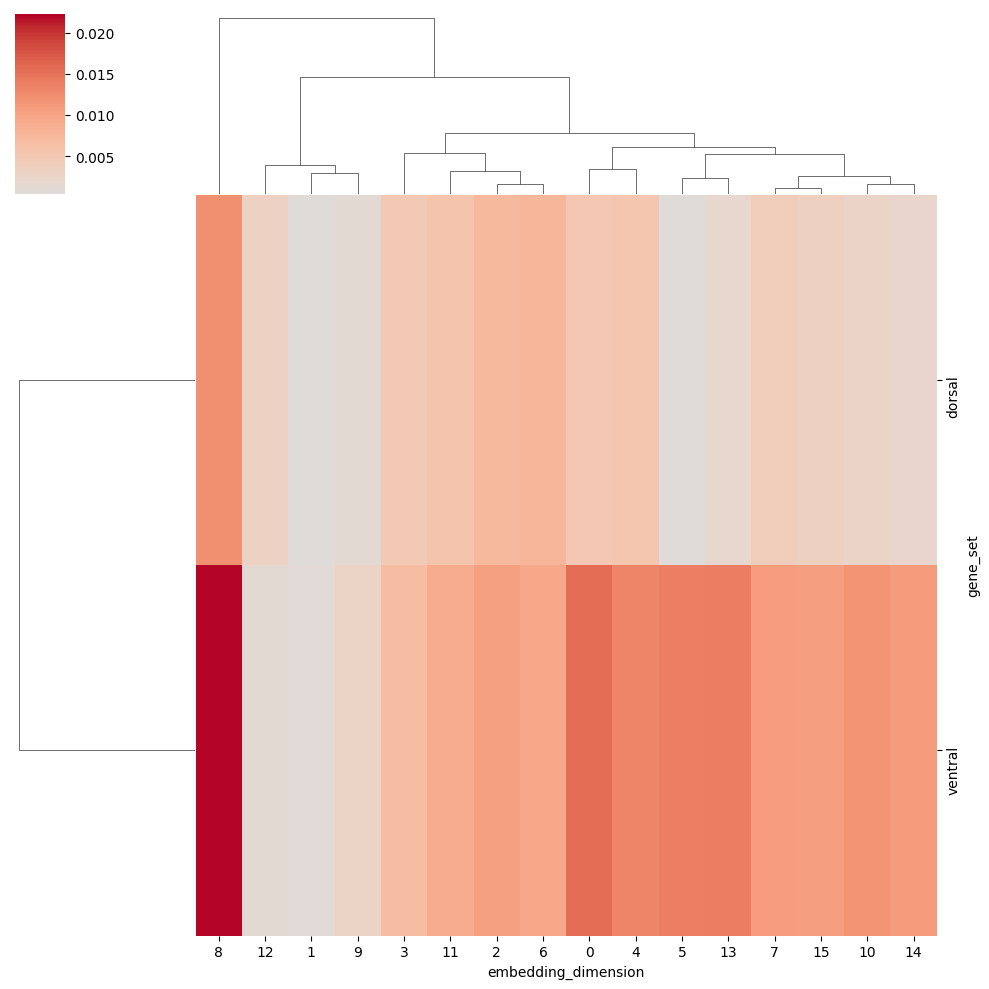

In [33]:
sns.clustermap(heatmap_data, cmap="coolwarm", center=0)
#plt.title("Local - Global: embedding dimension specificity")

In [ ]:
spatial_covariance_plot(
    ctrl_test,
    gene_sets = gene_sets,
    int_length = "global",   # "local" or "global", 
    #restrict_to = "TGFb",
    #emb_dim = 12, 
    cmap = "Greys"
)

### Cluster by distance 

In [38]:
gene_name = 'SHH'
threshold = 50 # can depend on the slide? 

if gene_name in ctrl_test.var_names:
    gene_expression = ctrl_test[:, gene_name].X
    if not isinstance(gene_expression, np.ndarray):
        gene_expression = gene_expression.toarray().flatten()  # For sparse matrices
    else:
        gene_expression = gene_expression.flatten()

    # Annotate cells in the obs field based on the expression threshold
    ctrl_test.obs[f'{gene_name}_status'] = np.where(gene_expression >= threshold, f'{gene_name}+', f'{gene_name}-')
else:
    print(f"Gene '{gene_name}' not found in adata.var_names.")


In [39]:
import squidpy as sq

/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


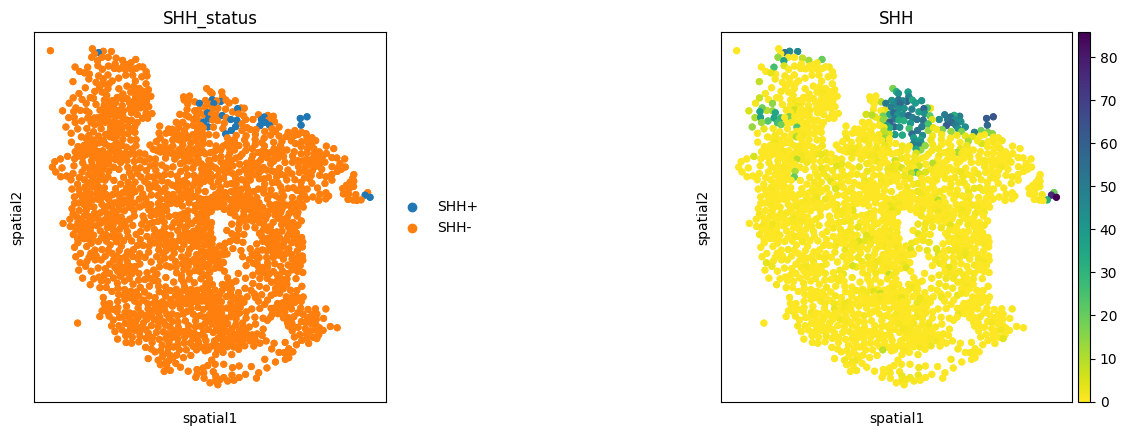

In [40]:
sq.pl.spatial_scatter(ctrl_test, 
                      color = ['SHH_status','SHH'],
                      cmap = 'viridis_r',
                      shape= None
                     )

In [41]:
# Coordinates
coords = ctrl_test.obsm["spatial"]
shh_coords = coords[ctrl_test.obs["SHH_status"] == "SHH+"]

# Compute distance to nearest SHH+ cell
from scipy.spatial import cKDTree
tree = cKDTree(shh_coords)
dist, _ = tree.query(coords, k=1)
ctrl_test.obs["dist_to_SHH+"] = dist

# Cluster cells based on distance
sc.pp.neighbors(ctrl_test, use_rep=None, n_neighbors=10)
ctrl_test.obs["distance_cluster"] = np.digitize(ctrl_test.obs["dist_to_SHH+"], bins=[10, 20, 30])  # arbitrary cutoffs


/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/scanpy/tools/_utils.py:40: UserWarning: You’re trying to run this on 88 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [42]:
dist = ctrl_test.obs["dist_to_SHH+"].to_numpy()

n_bins = 4
edges = np.quantile(dist, np.linspace(0, 1, n_bins + 1))
labels = [f"ring_{i+1}" for i in range(len(edges)-1)]

cats = pd.cut(dist, bins=edges, labels=labels, include_lowest=True, duplicates="drop")
# directly ensure it's ordered
cats = pd.Categorical(cats, categories=labels, ordered=True)

ctrl_test.obs["SHH_dist_ring"] = cats

In [ ]:
del ctrl_test.uns['SHH_dist_ring_colors']

/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/Users/sara.jimenez/miniconda3/envs/GT_long_range/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


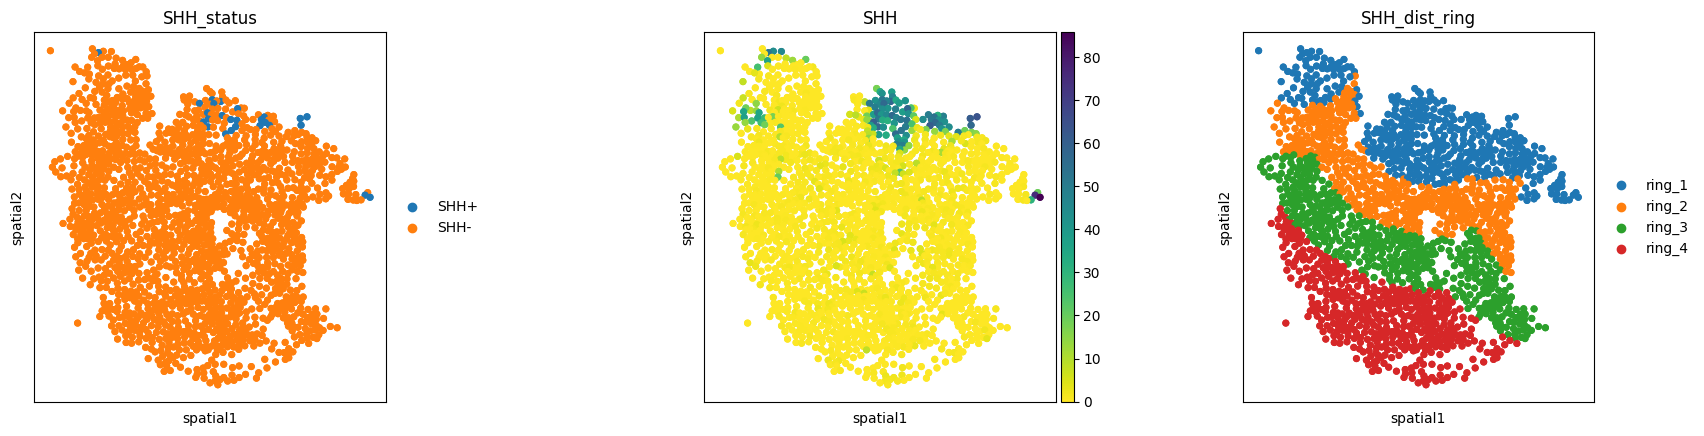

In [43]:
sq.pl.spatial_scatter(ctrl_test, 
                      color = ['SHH_status','SHH','SHH_dist_ring'],
                      cmap = 'viridis_r',
                      shape= None
                     )

In [44]:
ctrl_test

AnnData object with n_obs × n_vars = 1772 × 88
    obs: 'Cell', 'Area', 'x', 'y', 'sample', 'condition', 'organoid', 'obs_names', 'split', '_scvi_sample_key_0', '_scvi_group_key', '_cls_horizontal', '_cls_vertical', 'SHH_status', 'dist_to_SHH+', 'distance_cluster', 'SHH_dist_ring'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'SHH_status_colors', 'pca', 'neighbors', 'SHH_dist_ring_colors'
    obsm: 'spatial', '_local_emb', '_global_emb', '_attn_matrix', 'X_pca'
    varm: '_std_gene_loadings', 'PCs'
    layers: 'log1p_norm', 'norm_ftsqrt', 'raw', '_y_pred'
    obsp: 'distances', 'connectivities'

In [ ]:
# --- inputs
rings = ctrl_test.obs["SHH_dist_ring"].astype("category")
emb = ctrl_test.obsm["_local_emb"]  # shape: (n_cells, d)
d = emb.shape[1]

# --- make a DataFrame for easy grouping
cols = [f"dim_{i+1}" for i in range(d)]
df = pd.DataFrame(emb, columns=cols)
df["ring"] = rings.values

# ensure ordered rows by categorical order
ordered_rings = list(rings.cat.categories)

# --- aggregate: mean per ring (you can swap to .median() if you prefer)
M = (df.groupby("ring")[cols]
       .mean()
       .reindex(ordered_rings))

# --- optional: z-score each column so colors are comparable across dims
# comment this block if you prefer raw means
M = (M - M.mean(axis=0)) / (M.std(axis=0).replace(0, np.nan))
M = M.fillna(0.0)

# --- plot with matplotlib
fig_h = 0.6 * len(ordered_rings) + 2
fig_w = min(0.45 * d + 3, 18)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

im = ax.imshow(M.values, aspect="auto", interpolation="nearest")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Embedding (z-score)")

# ticks/labels
ax.set_yticks(range(len(ordered_rings)))
ax.set_yticklabels(ordered_rings)

# For many dims, thin x tick labels
step = 1 if d <= 30 else (2 if d <= 60 else 5)
ax.set_xticks(range(0, d, step))
ax.set_xticklabels([cols[i] for i in range(0, d, step)], rotation=90)

ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Distance-based cluster (rings)")
ax.set_title("Local embedding by SHH distance rings")

plt.tight_layout()
plt.show()